# Qwen3-0.6B QLoRA32 SFT: 3-Codebook train+val and test, history window 16

Final train+val SFT after the Qwen3-0.6B 3-codebook QLoRA32 CPT ablation. The epoch count is selected from the validation run by the runner.

## 1. Imports and config

Hyperparameters are copied from the validation SFT series. For the real run keep `DRY_RUN_STEPS = 0`.


In [1]:
from pathlib import Path
from importlib import metadata
from packaging.version import Version
import inspect
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from tqdm.auto import tqdm

from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, BitsAndBytesConfig
from peft import LoraConfig, PeftModel, TaskType, get_peft_model, prepare_model_for_kbit_training

os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

RUN_NAME = os.environ.get("SFT_RUN_NAME", "sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_bestepoch_allseen_v1")
BASE_CPT_DIR = ROOT / "data/processed/artifacts/cpt_qwen3_0_6b_base_sid_v2_3codebooks_plum_curriculum_qlora32_v1/final_merged"
SID_ARRAY_PATH = ROOT / "runs/qwen4b_rqvae_sid_v2_3codebooks_plum_ablation/SIDs_best.npy"
TRAIN_PATH = ROOT / "data/processed/splits/train.parquet"
VAL_PATH = ROOT / "data/processed/splits/val.parquet"
TEST_PATH = ROOT / "data/processed/splits/test.parquet"
USERS_PATH = ROOT / "data/raw/ml-1m/users.dat"

OUTPUT_DIR = ROOT / "data/processed/artifacts" / RUN_NAME
TMP_TRAINER_DIR = OUTPUT_DIR / "trainer_tmp"
EPOCH_ADAPTERS_DIR = OUTPUT_DIR / "epoch_adapters"
FINAL_ADAPTER_DIR = OUTPUT_DIR / "final_adapter"
FINAL_MERGED_DIR = OUTPUT_DIR / "final_merged"

SEED = 42
MAX_EPOCHS = int(os.environ.get("SFT_MAX_EPOCHS", "2"))
PRIMARY_METRIC = "recall@10"

MIN_HISTORY_LEN = 16
TRAIN_HISTORY_WINDOW_CHOICES = [16]
EVAL_HISTORY_LEN = 16
TARGETS_PER_USER_PER_EPOCH = 4
RECENT_TARGET_FRACTION = 0.65
INCLUDE_RATINGS = True
INCLUDE_USER_FEATURES = True
FILTER_SEEN = True
SEEN_FILTER_FIELD = "all_seen_item_idx"

MAX_SEQ_LENGTH = 192
MAX_TARGET_TOKENS = 8
TOP_K = 10
EVAL_BEAM_SIZE = 20
EVAL_NUM_RETURN_SEQUENCES = 20
FULL_TEST_MAX_USERS = None
RUN_FINAL_FULL_TEST = False
RUN_STRICT_FULL_SEEN_TEST = False

LORA_R = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0.05
LEARNING_RATE = 1e-4
WARMUP_RATIO = 0.03
WEIGHT_DECAY = 0.01
PER_DEVICE_BATCH = 8
GRADIENT_ACCUMULATION_STEPS = 8
LOGGING_STEPS = 20
SAVE_MERGED_FINAL = False
DRY_RUN_STEPS = 0
FORCE_RETRAIN = True
FORCE_REEVAL_TEST = False
SKIP_MODEL_LOAD_FOR_REPORT = False
RUN_QUICK_INFERENCE = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BF16 = DEVICE == "cuda" and torch.cuda.is_bf16_supported()
FP16 = DEVICE == "cuda" and not BF16
DTYPE = torch.bfloat16 if BF16 else (torch.float16 if FP16 else torch.float32)
PRECISION_MODE = "bf16" if BF16 else ("fp16" if FP16 else "fp32")

if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.cuda.empty_cache()

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EPOCH_ADAPTERS_DIR.mkdir(parents=True, exist_ok=True)

print("root:", ROOT)
print("base CPT:", BASE_CPT_DIR)
print("device:", DEVICE, PRECISION_MODE)
print("effective batch:", PER_DEVICE_BATCH * GRADIENT_ACCUMULATION_STEPS)


root: C:\Users\User\plum-ml1m-repro
base CPT: C:\Users\User\plum-ml1m-repro\data\processed\artifacts\cpt_qwen3_0_6b_base_sid_v2_3codebooks_plum_curriculum_qlora32_v1\final_merged
device: cuda bf16
effective batch: 64


## 2. Load data

SFT training uses `train + val`. Test stays untouched until final evaluation.


In [2]:
assert BASE_CPT_DIR.exists(), BASE_CPT_DIR
train = pd.read_parquet(TRAIN_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").reset_index(drop=True)
val = pd.read_parquet(VAL_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").reset_index(drop=True)
test = pd.read_parquet(TEST_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").reset_index(drop=True)
users = pd.read_csv(
    USERS_PATH,
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip"],
    encoding="latin-1",
)
sids = np.load(SID_ARRAY_PATH)
assert sids.shape[1] == 3, sids.shape

print("train/val/test:", len(train), len(val), len(test))
print("users:", len(users), "items:", len(sids))
train.head()

train/val/test: 988129 6040 6040
users: 6040 items: 3706


,user_id,movie_id,rating,timestamp,user_idx,item_idx,pos,len
0,1,3186,4,978300019,0,2969,0,53
1,1,1270,5,978300055,0,1178,1,53
2,1,1721,4,978300055,0,1574,2,53
3,1,1022,5,978300055,0,957,3,53
4,1,2340,3,978300103,0,2147,4,53


## 3. Tokenizer, SID tokens, and collision suffixes

SID collisions are rare, but suffixes keep target sequences item-level unique.

In [3]:
BOS = "<bos>"
EOS = "<eos>"
PAD = "<pad>"
USER_OPEN = "<user>"
USER_CLOSE = "</user>"
HIST = "<hist>"
EVENT_OPEN = "<e>"
EVENT_CLOSE = "</e>"
TASK_REC = "<task_rec>"
NEXT = "<next>"


def base_sid_tokens(sid):
    return [f"<sid_{level}_{int(code)}>" for level, code in enumerate(sid)]


def rating_token(rating):
    return f"<rat_{int(rating)}>"


def user_tokens(row):
    return [f"<gen_{row.gender}>", f"<age_{int(row.age)}>", f"<occ_{int(row.occupation)}>"]

sid_keys = [tuple(int(x) for x in sid) for sid in sids]
sid_to_items = {}
for item_idx, key in enumerate(sid_keys):
    sid_to_items.setdefault(key, []).append(int(item_idx))

item_dup_suffix = {}
dup_tokens = []
for key, items in sid_to_items.items():
    if len(items) > 1:
        for dup_i, item_idx in enumerate(sorted(items)):
            tok = f"<dup_{dup_i}>"
            item_dup_suffix[int(item_idx)] = tok
            dup_tokens.append(tok)

def item_sid_tokens(item_idx):
    tokens = base_sid_tokens(sids[int(item_idx)])
    if int(item_idx) in item_dup_suffix:
        tokens = tokens + [item_dup_suffix[int(item_idx)]]
    return tokens


def load_tokenizer(path):
    try:
        return AutoTokenizer.from_pretrained(path, use_fast=True, fix_mistral_regex=True, local_files_only=True)
    except TypeError:
        return AutoTokenizer.from_pretrained(path, use_fast=True, local_files_only=True)


tokenizer = load_tokenizer(BASE_CPT_DIR)
base_vocab_size = len(tokenizer)
extra_tokens = [TASK_REC, NEXT, *sorted(set(dup_tokens))]
added = tokenizer.add_tokens([tok for tok in extra_tokens if tok not in tokenizer.get_vocab()], special_tokens=True)
new_token_ids = sorted(set(int(x) for x in tokenizer.convert_tokens_to_ids(extra_tokens)))

print("base vocab:", base_vocab_size, "current vocab:", len(tokenizer), "added:", added)
print("SID collisions:", sum(len(v) > 1 for v in sid_to_items.values()), "dup items:", len(item_dup_suffix))
print("new token ids:", len(new_token_ids))

base vocab: 152151 current vocab: 152156 added: 5
SID collisions: 20 dup items: 42
new token ids: 5


## 4. Build trie and item maps

The trie constrains generation to valid item token sequences only.

In [4]:
def token_ids_for_item(item_idx):
    return tuple(int(x) for x in tokenizer.convert_tokens_to_ids(item_sid_tokens(item_idx)))

item_to_token_ids = {int(i): token_ids_for_item(i) for i in range(len(sids))}
token_ids_to_item = {v: k for k, v in item_to_token_ids.items()}
assert len(token_ids_to_item) == len(item_to_token_ids)

TRIE = {}
for ids in item_to_token_ids.values():
    node = TRIE
    for token_id in ids:
        node = node.setdefault(int(token_id), {})
    node[int(tokenizer.eos_token_id)] = {}

EOS_ID = int(tokenizer.eos_token_id)
PAD_ID = int(tokenizer.pad_token_id)
print("valid item sequences:", len(item_to_token_ids))
print("max target tokens:", max(len(x) for x in item_to_token_ids.values()) + 1)

valid item sequences: 3706
max target tokens: 5


## 5. Prompt and example encoding

In [5]:
users_by_id = users.set_index("user_id", drop=False)

train_events_by_user = {
    int(user_id): group.sort_values(["timestamp", "pos", "item_idx"], kind="mergesort").to_dict("records")
    for user_id, group in train.groupby("user_id", sort=False)
}

val_target_by_user = {
    int(row.user_id): row._asdict()
    for row in val.sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").itertuples(index=False)
}

test_target_by_user = {
    int(row.user_id): row._asdict()
    for row in test.sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").itertuples(index=False)
}

train_plus_val_events_by_user = {
    int(user_id): group.sort_values(["timestamp", "pos", "item_idx"], kind="mergesort").to_dict("records")
    for user_id, group in pd.concat([train, val], ignore_index=True).groupby("user_id", sort=False)
}


def event_tokens(event):
    tokens = [EVENT_OPEN]
    tokens.extend(item_sid_tokens(event["item_idx"]))
    if INCLUDE_RATINGS:
        tokens.append(rating_token(event["rating"]))
    tokens.append(EVENT_CLOSE)
    return tokens


def prompt_prefix_tokens(user_id):
    tokens = [BOS, TASK_REC]
    if INCLUDE_USER_FEATURES and int(user_id) in users_by_id.index:
        tokens.append(USER_OPEN)
        tokens.extend(user_tokens(users_by_id.loc[int(user_id)]))
        tokens.append(USER_CLOSE)
    tokens.append(HIST)
    return tokens


def fit_prompt(prefix, history_events, target_tokens):
    event_blocks = [event_tokens(event) for event in history_events]
    while event_blocks:
        prompt_tokens = prefix + [tok for block in event_blocks for tok in block] + [NEXT]
        if len(prompt_tokens) + len(target_tokens) <= MAX_SEQ_LENGTH:
            return prompt_tokens
        event_blocks = event_blocks[1:]
    prompt_tokens = prefix + [NEXT]
    if len(prompt_tokens) + len(target_tokens) > MAX_SEQ_LENGTH:
        raise ValueError("Prompt prefix plus target exceeds MAX_SEQ_LENGTH")
    return prompt_tokens


def encode_sft_example(user_id, history_events, target_event, split, seen_events=None):
    target_item = int(target_event["item_idx"])
    target_tokens = item_sid_tokens(target_item) + [EOS]
    prompt_tokens = fit_prompt(prompt_prefix_tokens(user_id), history_events, target_tokens)
    all_tokens = prompt_tokens + target_tokens
    input_ids = tokenizer.convert_tokens_to_ids(all_tokens)
    labels = [-100] * len(prompt_tokens) + input_ids[len(prompt_tokens):]

    if any(token_id == tokenizer.unk_token_id for token_id in input_ids):
        bad = [tok for tok, token_id in zip(all_tokens, input_ids) if token_id == tokenizer.unk_token_id]
        raise ValueError(f"Unknown tokens: {bad[:10]}")

    seen_events = history_events if seen_events is None else seen_events

    return {
        "input_ids": input_ids,
        "labels": labels,
        "prompt_length": len(prompt_tokens),
        "user_id": int(user_id),
        "split": split,
        "target_item_idx": target_item,
        "history_item_idx": [int(event["item_idx"]) for event in history_events],
        "all_seen_item_idx": [int(event["item_idx"]) for event in seen_events],
    }

trainval_events_by_user = train_plus_val_events_by_user
print("train users:", len(train_events_by_user), "train+val users:", len(trainval_events_by_user))


train users: 6040 train+val users: 6040


## 6. Dynamic train+val sampler

Each epoch resamples target positions from `train+val`. Every example has at least 16 history events.


In [6]:
def sample_target_positions(n_events, rng):
    valid = np.arange(MIN_HISTORY_LEN, n_events, dtype=np.int32)
    if len(valid) == 0:
        return []

    n_recent = int(round(TARGETS_PER_USER_PER_EPOCH * RECENT_TARGET_FRACTION))
    n_random = TARGETS_PER_USER_PER_EPOCH - n_recent
    recent_pool_start = max(MIN_HISTORY_LEN, int(n_events * 0.70))
    recent_pool = np.arange(recent_pool_start, n_events, dtype=np.int32)
    if len(recent_pool) == 0:
        recent_pool = valid

    recent = rng.choice(recent_pool, size=min(n_recent, len(recent_pool)), replace=len(recent_pool) < n_recent)
    random_pos = rng.choice(valid, size=min(n_random, len(valid)), replace=len(valid) < n_random)
    return sorted(set(int(x) for x in np.concatenate([recent, random_pos])))


def build_train_examples_for_epoch(epoch):
    rng = np.random.default_rng(SEED + epoch)
    examples = []
    stats = []

    for user_id, events in trainval_events_by_user.items():
        positions = sample_target_positions(len(events), rng)
        for target_pos in positions:
            target_event = events[target_pos]
            window = int(rng.choice(TRAIN_HISTORY_WINDOW_CHOICES))
            start = max(0, target_pos - window)
            history_events = events[start:target_pos]
            if len(history_events) < MIN_HISTORY_LEN:
                continue
            ex = encode_sft_example(user_id, history_events, target_event, split="train")
            examples.append(ex)
            stats.append((len(history_events), len(ex["input_ids"])))

    rng.shuffle(examples)
    stats = np.array(stats, dtype=np.int32) if stats else np.zeros((0, 2), dtype=np.int32)
    epoch_stats = {
        "epoch": int(epoch),
        "examples": int(len(examples)),
        "history_p50": int(np.percentile(stats[:, 0], 50)) if len(stats) else 0,
        "history_p95": int(np.percentile(stats[:, 0], 95)) if len(stats) else 0,
        "length_p50": int(np.percentile(stats[:, 1], 50)) if len(stats) else 0,
        "length_p95": int(np.percentile(stats[:, 1], 95)) if len(stats) else 0,
        "length_max": int(stats[:, 1].max()) if len(stats) else 0,
    }
    return examples, epoch_stats

train_preview, train_preview_stats = build_train_examples_for_epoch(0)
print("preview examples:", len(train_preview))
train_preview_stats

preview examples: 23485


{'epoch': 0,
 'examples': 23485,
 'history_p50': 16,
 'history_p95': 16,
 'length_p50': 109,
 'length_p95': 111,
 'length_max': 115}

## 7. Test examples

Test uses `train+val` as context and `test.parquet` as the next-item target.


In [7]:
def build_eval_examples(split="test", max_users=None, seed=SEED):
    if split == "val":
        context_by_user = train_events_by_user
        target_by_user = val_target_by_user
    elif split == "test":
        context_by_user = train_plus_val_events_by_user
        target_by_user = test_target_by_user
    else:
        raise ValueError("split must be 'val' or 'test'")

    user_ids = sorted(target_by_user.keys())
    if max_users is not None:
        rng = np.random.default_rng(seed)
        user_ids = sorted(rng.choice(user_ids, size=min(max_users, len(user_ids)), replace=False).tolist())

    examples = []
    for user_id in user_ids:
        full_history = context_by_user.get(int(user_id), [])
        history = full_history[-EVAL_HISTORY_LEN:]
        if len(history) < MIN_HISTORY_LEN:
            continue
        examples.append(
            encode_sft_example(
                user_id,
                history,
                target_by_user[user_id],
                split=split,
                seen_events=full_history,
            )
        )
    return examples

full_test_examples = build_eval_examples("test", max_users=FULL_TEST_MAX_USERS)
print("full test examples:", len(full_test_examples))


full test examples: 6040


## 8. Dataset and collator

In [8]:
class SFTListDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        return {"input_ids": ex["input_ids"], "labels": ex["labels"]}


class SFTCollator:
    def __init__(self, tokenizer, pad_to_multiple_of=8):
        self.tokenizer = tokenizer
        self.pad_to_multiple_of = pad_to_multiple_of

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)
        if self.pad_to_multiple_of:
            max_len = int(math.ceil(max_len / self.pad_to_multiple_of) * self.pad_to_multiple_of)

        input_ids, labels, attention_mask = [], [], []
        for f in features:
            ids = list(f["input_ids"])
            lab = list(f["labels"])
            pad_len = max_len - len(ids)
            input_ids.append(ids + [self.tokenizer.pad_token_id] * pad_len)
            labels.append(lab + [-100] * pad_len)
            attention_mask.append([1] * len(ids) + [0] * pad_len)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
        }

collator = SFTCollator(tokenizer)

## 9. Load Qwen CPT and attach SFT LoRA

In [9]:
def load_causal_lm(path):
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=DTYPE,
        bnb_4bit_use_double_quant=True,
    )
    kwargs = {
        "quantization_config": quant_config,
        "device_map": {"": 0} if DEVICE == "cuda" else None,
        "local_files_only": True,
        "trust_remote_code": False,
        "low_cpu_mem_usage": True,
    }
    kwargs = {k: v for k, v in kwargs.items() if v is not None}
    return AutoModelForCausalLM.from_pretrained(path, **kwargs)

existing_final_artifacts = FINAL_ADAPTER_DIR.exists() and (OUTPUT_DIR / "metrics.json").exists()

if existing_final_artifacts and SKIP_MODEL_LOAD_FOR_REPORT and not FORCE_RETRAIN:
    model = None
    print("Existing final adapter and metrics found; skipping train-model load for report execution.")
else:
    model = load_causal_lm(BASE_CPT_DIR)
    model.resize_token_embeddings(len(tokenizer), mean_resizing=False)
    model.config.bos_token_id = tokenizer.bos_token_id
    model.config.eos_token_id = tokenizer.eos_token_id
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False

    model = prepare_model_for_kbit_training(
        model,
        use_gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": True},
    )

    lora_kwargs = {
        "task_type": TaskType.CAUSAL_LM,
        "r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "bias": "none",
        "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        "trainable_token_indices": {"embed_tokens": new_token_ids, "lm_head": new_token_ids},
    }
    peft_config = LoraConfig(**lora_kwargs)
    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()


trainable params: 20,190,208 || all params: 616,465,408 || trainable%: 3.2752


## 10. Trie decoding and metrics

In [10]:
def set_generation_mode(model):
    model.eval()
    model.config.use_cache = True
    if hasattr(model, "gradient_checkpointing_disable"):
        model.gradient_checkpointing_disable()
    torch.cuda.empty_cache() if DEVICE == "cuda" else None


def set_training_mode(model):
    model.train()
    model.config.use_cache = False
    if hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})


def trie_allowed_tokens(prompt_length):
    def allowed(_batch_id, input_ids):
        node = TRIE
        generated = input_ids[prompt_length:].tolist()
        for token_id in generated:
            token_id = int(token_id)
            if token_id not in node:
                return [EOS_ID]
            node = node[token_id]
        return sorted(node.keys()) if node else [EOS_ID]
    return allowed


def decode_generated_item(sequence_ids, prompt_length):
    new_ids = []
    for token_id in sequence_ids[prompt_length:].tolist():
        token_id = int(token_id)
        if token_id in {EOS_ID, PAD_ID}:
            break
        new_ids.append(token_id)
    return token_ids_to_item.get(tuple(new_ids))


def generate_candidates(model, example, beam_size=EVAL_BEAM_SIZE, top_k=TOP_K, num_return_sequences=EVAL_NUM_RETURN_SEQUENCES, filter_seen=FILTER_SEEN, seen_field=SEEN_FILTER_FIELD):
    prompt_ids = example["input_ids"][:example["prompt_length"]]
    input_ids = torch.tensor([prompt_ids], dtype=torch.long, device=DEVICE)
    attention_mask = torch.ones_like(input_ids)
    seen = set(example.get(seen_field, example.get("history_item_idx", []))) if filter_seen else set()
    num_return_sequences = min(int(num_return_sequences), int(beam_size))

    with torch.inference_mode():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_TARGET_TOKENS,
            num_beams=beam_size,
            num_return_sequences=num_return_sequences,
            do_sample=False,
            early_stopping=True,
            pad_token_id=PAD_ID,
            eos_token_id=EOS_ID,
            prefix_allowed_tokens_fn=trie_allowed_tokens(len(prompt_ids)),
            use_cache=True,
        )

    candidates = []
    raw_items = []
    invalid = 0
    seen_generated = 0
    used = set()

    for seq in outputs:
        item = decode_generated_item(seq, len(prompt_ids))
        if item is None:
            invalid += 1
            continue
        raw_items.append(int(item))
        if item in seen:
            seen_generated += 1
            continue
        if item in used:
            continue
        candidates.append(int(item))
        used.add(int(item))
        if len(candidates) >= top_k:
            break

    return {"candidates": candidates, "raw_items": raw_items, "invalid_sid_count": invalid, "seen_generated_count": seen_generated, "generated_count": int(len(outputs))}


def recall_at_k(candidates, target, k):
    return float(int(int(target) in candidates[:k]))


def ndcg_at_k(candidates, target, k):
    target = int(target)
    for rank, item in enumerate(candidates[:k], start=1):
        if int(item) == target:
            return 1.0 / math.log2(rank + 1)
    return 0.0


def mrr_at_k(candidates, target, k):
    target = int(target)
    for rank, item in enumerate(candidates[:k], start=1):
        if int(item) == target:
            return 1.0 / rank
    return 0.0


def evaluate_model(model, examples, name="test", beam_size=EVAL_BEAM_SIZE, top_k=TOP_K, num_return_sequences=EVAL_NUM_RETURN_SEQUENCES, seen_field=SEEN_FILTER_FIELD):
    set_generation_mode(model)
    records = []
    for ex in tqdm(examples, desc=f"eval {name}", leave=False):
        gen = generate_candidates(model, ex, beam_size=beam_size, top_k=top_k, num_return_sequences=num_return_sequences, seen_field=seen_field)
        records.append({"user_id": ex["user_id"], "target_item_idx": int(ex["target_item_idx"]), **gen})

    metrics = {"split": name, "n": len(records)}
    recommended = set()
    invalid = 0
    generated = 0
    seen_generated = 0
    candidate_counts = []

    for rec in records:
        target = int(rec["target_item_idx"])
        candidates = rec["candidates"]
        recommended.update(candidates)
        candidate_counts.append(len(candidates))
        invalid += int(rec["invalid_sid_count"])
        generated += int(rec["generated_count"])
        seen_generated += int(rec["seen_generated_count"])
        for k in [1, 5, 10]:
            metrics[f"recall@{k}"] = metrics.get(f"recall@{k}", 0.0) + recall_at_k(candidates, target, k)
            metrics[f"ndcg@{k}"] = metrics.get(f"ndcg@{k}", 0.0) + ndcg_at_k(candidates, target, k)
            metrics[f"mrr@{k}"] = metrics.get(f"mrr@{k}", 0.0) + mrr_at_k(candidates, target, k)

    n = max(len(records), 1)
    for key in list(metrics):
        if key.startswith(("recall@", "ndcg@", "mrr@")):
            metrics[key] = metrics[key] / n
    metrics["coverage@10"] = int(len(recommended))
    metrics["avg_candidates"] = float(np.mean(candidate_counts)) if candidate_counts else 0.0
    metrics["invalid_sid_rate"] = float(invalid / max(generated, 1))
    metrics["seen_generated_rate"] = float(seen_generated / max(generated, 1))
    return metrics, records

## 11. Training helpers

The final run uses the history-window-16 protocol selected on validation. It trains for one epoch on train+val and evaluates the test split once. No test-based model selection is used.


In [11]:
def make_training_args(epoch):
    args_kwargs = {
        "output_dir": str(TMP_TRAINER_DIR / f"epoch_{epoch:03d}"),
        "overwrite_output_dir": True,
        "num_train_epochs": 1,
        "max_steps": DRY_RUN_STEPS if DRY_RUN_STEPS > 0 else -1,
        "learning_rate": LEARNING_RATE,
        "warmup_ratio": WARMUP_RATIO,
        "weight_decay": WEIGHT_DECAY,
        "per_device_train_batch_size": PER_DEVICE_BATCH,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "gradient_checkpointing": True,
        "logging_steps": LOGGING_STEPS,
        "save_strategy": "no",
        "eval_strategy": "no",
        "fp16": FP16,
        "bf16": BF16,
        "tf32": DEVICE == "cuda",
        "report_to": "none",
        "dataloader_num_workers": 0,
        "dataloader_pin_memory": DEVICE == "cuda",
        "remove_unused_columns": False,
        "optim": "paged_adamw_8bit" if DEVICE == "cuda" else "adamw_torch",
    }
    args_params = inspect.signature(TrainingArguments).parameters
    return TrainingArguments(**{k: v for k, v in args_kwargs.items() if k in args_params})


def save_adapter_bundle(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    if model is None:
        raise RuntimeError("model is not loaded; cannot save adapter")
    model.save_pretrained(str(path))
    tokenizer.save_pretrained(str(path))


def merge_final_adapter(adapter_dir=FINAL_ADAPTER_DIR, merged_dir=FINAL_MERGED_DIR):
    adapter_dir = Path(adapter_dir)
    merged_dir = Path(merged_dir)
    tok = load_tokenizer(adapter_dir)
    base = load_causal_lm(BASE_CPT_DIR)
    base.resize_token_embeddings(len(tok), mean_resizing=False)
    peft_model = PeftModel.from_pretrained(base, adapter_dir).to(DEVICE)
    merged = peft_model.merge_and_unload()
    merged_dir.mkdir(parents=True, exist_ok=True)
    merged.save_pretrained(str(merged_dir), safe_serialization=True, max_shard_size="2GB")
    tok.save_pretrained(str(merged_dir))
    return merged_dir


## 12. Train SFT on train+val

Exactly one epoch, selected from the 3-codebook validation run. Metrics during training are train-only; test is evaluated after training.


In [12]:
metrics_path = OUTPUT_DIR / "metrics.json"
summary_path = OUTPUT_DIR / "summary.json"

if metrics_path.exists() and FINAL_ADAPTER_DIR.exists() and not FORCE_RETRAIN:
    metrics_log = json.loads(metrics_path.read_text(encoding="utf-8"))
    summary = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}
    print("Existing training artifacts found; skipping SFT training.")
    print(json.dumps(summary, indent=2, ensure_ascii=False))
else:
    if model is None:
        raise RuntimeError("model was skipped but training artifacts are missing. Set SKIP_MODEL_LOAD_FOR_REPORT=False.")

    metrics_log = []
    started_at = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        set_training_mode(model)
        train_examples, epoch_data_stats = build_train_examples_for_epoch(epoch)
        train_ds = SFTListDataset(train_examples)

        trainer_kwargs = {
            "model": model,
            "args": make_training_args(epoch),
            "train_dataset": train_ds,
            "data_collator": collator,
        }
        trainer_params = inspect.signature(Trainer).parameters
        if "processing_class" in trainer_params:
            trainer_kwargs["processing_class"] = tokenizer
        else:
            trainer_kwargs["tokenizer"] = tokenizer

        trainer = Trainer(**trainer_kwargs)
        train_output = trainer.train()

        epoch_adapter_dir = EPOCH_ADAPTERS_DIR / f"epoch_{epoch:02d}"
        save_adapter_bundle(epoch_adapter_dir)

        row = {
            "epoch": epoch,
            "train_loss": float(train_output.metrics.get("train_loss", np.nan)),
            "train_runtime": float(train_output.metrics.get("train_runtime", np.nan)),
            "epoch_adapter_dir": str(epoch_adapter_dir),
            **epoch_data_stats,
        }
        metrics_log.append(row)
        pd.DataFrame(metrics_log).to_json(metrics_path, orient="records", indent=2)
        print(json.dumps(row, indent=2))

        if DRY_RUN_STEPS > 0:
            print("DRY_RUN_STEPS > 0: stopping after smoke epoch.")
            break

    save_adapter_bundle(FINAL_ADAPTER_DIR)
    summary = {
        "protocol": "SFT train on train+val for the Qwen3 validation-selected w16 protocol; test is evaluated in a clean external process",
        "epochs_completed": len(metrics_log),
        "train_seconds": time.time() - started_at,
        "final_adapter_dir": str(FINAL_ADAPTER_DIR),
        "epoch_adapters_dir": str(EPOCH_ADAPTERS_DIR),
    }
    with summary_path.open("w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    if SAVE_MERGED_FINAL and DRY_RUN_STEPS == 0:
        summary["final_merged_dir"] = str(merge_final_adapter())
        with summary_path.open("w", encoding="utf-8") as f:
            json.dump(summary, f, ensure_ascii=False, indent=2)

summary


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151670, 'bos_token_id': 151669, 'pad_token_id': 151671}.


Step,Training Loss
20,3.340400
40,1.476500
60,1.421900
80,1.418100
100,1.420600
120,1.395500
140,1.418100
160,1.401900
180,1.391800
200,1.392200


C:\Users\User\.conda\conda.new\Lib\site-packages\peft\utils\save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


{
  "epoch": 1,
  "train_loss": 1.5022492149601812,
  "train_runtime": 1086.6484,
  "epoch_adapter_dir": "C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_e3_allseen_v1\\epoch_adapters\\epoch_01",
  "examples": 23489,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 109,
  "length_p95": 111,
  "length_max": 115
}


Step,Training Loss
20,1.371100
40,1.365100
60,1.369800
80,1.367900
100,1.399000
120,1.359600
140,1.349800
160,1.354300
180,1.372900
200,1.383200


{
  "epoch": 2,
  "train_loss": 1.365674969935612,
  "train_runtime": 1079.9459,
  "epoch_adapter_dir": "C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_e3_allseen_v1\\epoch_adapters\\epoch_02",
  "examples": 23488,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 109,
  "length_p95": 111,
  "length_max": 115
}


Step,Training Loss
20,1.373900
40,1.363900
60,1.348200
80,1.395900
100,1.371800
120,1.356300
140,1.333800
160,1.367400
180,1.338000
200,1.342800


{
  "epoch": 3,
  "train_loss": 1.3546498728835064,
  "train_runtime": 1081.1727,
  "epoch_adapter_dir": "C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_e3_allseen_v1\\epoch_adapters\\epoch_03",
  "examples": 23490,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 109,
  "length_p95": 111,
  "length_max": 116
}


{'protocol': 'SFT train on train+val for the Qwen3 validation-selected w16 protocol; test is evaluated in a clean external process',
 'epochs_completed': 3,
 'train_seconds': 3291.8959531784058,
 'final_adapter_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_e3_allseen_v1\\final_adapter',
 'epoch_adapters_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_e3_allseen_v1\\epoch_adapters'}

## 13. Final full test on final adapter

This is the first and only test evaluation in this notebook. The primary metric keeps the same visible-window filtering protocol as the validation series.


In [13]:
print("RUN_FINAL_FULL_TEST:", RUN_FINAL_FULL_TEST, "(test is run by scripts/qwen3_sft_beam_sweep.py after training)")
print("FINAL_ADAPTER_DIR:", FINAL_ADAPTER_DIR)
print("final exists:", FINAL_ADAPTER_DIR.exists())
print("full test examples:", len(full_test_examples))
print("seen filter field:", SEEN_FILTER_FIELD)


RUN_FINAL_FULL_TEST: False (test is run by scripts/qwen3_sft_beam_sweep.py after training)
FINAL_ADAPTER_DIR: C:\Users\User\plum-ml1m-repro\data\processed\artifacts\sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_e3_allseen_v1\final_adapter
final exists: True
full test examples: 6040
seen filter field: all_seen_item_idx


In [14]:
final_test_metrics = None
strict_full_seen_test_metrics = None
final_test_path = OUTPUT_DIR / "final_test_metrics.json"
strict_test_path = OUTPUT_DIR / "strict_full_seen_test_metrics.json"

if final_test_path.exists() and not FORCE_REEVAL_TEST:
    final_test_metrics = json.loads(final_test_path.read_text(encoding="utf-8"))
    print("Existing final test metrics found; skipping full-test reevaluation.")
elif RUN_FINAL_FULL_TEST and FINAL_ADAPTER_DIR.exists():
    tokenizer = load_tokenizer(FINAL_ADAPTER_DIR)
    base = load_causal_lm(BASE_CPT_DIR)
    base.resize_token_embeddings(len(tokenizer), mean_resizing=False)
    eval_model = PeftModel.from_pretrained(base, FINAL_ADAPTER_DIR).to(DEVICE)
    final_test_metrics, _ = evaluate_model(
        eval_model,
        full_test_examples,
        name="test_full_final_prompt_window_seen",
        seen_field="history_item_idx",
    )
    with final_test_path.open("w", encoding="utf-8") as f:
        json.dump(final_test_metrics, f, ensure_ascii=False, indent=2)

if RUN_STRICT_FULL_SEEN_TEST:
    if strict_test_path.exists() and not FORCE_REEVAL_TEST:
        strict_full_seen_test_metrics = json.loads(strict_test_path.read_text(encoding="utf-8"))
    elif FINAL_ADAPTER_DIR.exists():
        if "eval_model" not in globals():
            tokenizer = load_tokenizer(FINAL_ADAPTER_DIR)
            base = load_causal_lm(BASE_CPT_DIR)
            base.resize_token_embeddings(len(tokenizer), mean_resizing=False)
            eval_model = PeftModel.from_pretrained(base, FINAL_ADAPTER_DIR).to(DEVICE)
        strict_full_seen_test_metrics, _ = evaluate_model(
            eval_model,
            full_test_examples,
            name="test_full_final_all_seen_filter",
            seen_field="all_seen_item_idx",
        )
        with strict_test_path.open("w", encoding="utf-8") as f:
            json.dump(strict_full_seen_test_metrics, f, ensure_ascii=False, indent=2)

final_test_metrics, strict_full_seen_test_metrics


(None, None)

## 14. Plots


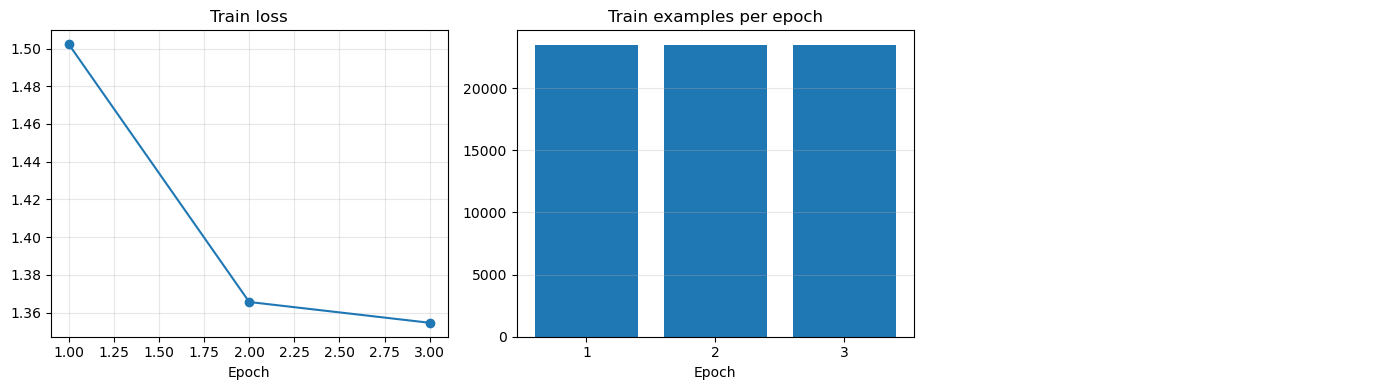

In [15]:
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame(metrics_log)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(metrics_df["epoch"], metrics_df["train_loss"], marker="o")
axes[0].set_title("Train loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(True, alpha=0.3)

axes[1].bar(metrics_df["epoch"].astype(str), metrics_df["examples"])
axes[1].set_title("Train examples per epoch")
axes[1].set_xlabel("Epoch")
axes[1].grid(True, axis="y", alpha=0.3)

if final_test_metrics:
    names = ["recall@1", "recall@5", "recall@10", "ndcg@10", "mrr@10"]
    vals = [final_test_metrics.get(name, 0.0) for name in names]
    axes[2].bar(names, vals)
    axes[2].set_title("Final test metrics")
    axes[2].tick_params(axis="x", rotation=30)
else:
    axes[2].axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sft_trainval_test_curves.png", dpi=160)
plt.show()


## 15. Quick inference examples


In [16]:
def render_prompt(example):
    return tokenizer.decode(example["input_ids"][:example["prompt_length"]], skip_special_tokens=False)

if RUN_QUICK_INFERENCE and FINAL_ADAPTER_DIR.exists():
    if "eval_model" not in globals():
        tokenizer = load_tokenizer(FINAL_ADAPTER_DIR)
        base = load_causal_lm(BASE_CPT_DIR)
        base.resize_token_embeddings(len(tokenizer), mean_resizing=False)
        eval_model = PeftModel.from_pretrained(base, FINAL_ADAPTER_DIR).to(DEVICE)
    ex = full_test_examples[0]
    gen = generate_candidates(eval_model, ex, beam_size=EVAL_BEAM_SIZE, top_k=TOP_K)
    print(render_prompt(ex))
    print("target item_idx:", ex["target_item_idx"])
    print("candidates:", gen["candidates"])
else:
    print("Quick inference is skipped in the automated final-test run.")


Quick inference is skipped in the automated final-test run.


## 16. Config snapshot


In [17]:
config = {
    "run_name": RUN_NAME,
    "base_cpt_dir": str(BASE_CPT_DIR),
    "sid_array_path": str(SID_ARRAY_PATH),
    "task": "next_watched_item_all_ratings_final_test",
    "protocol": "train+val SFT -> full test evaluation; w16, 1 epoch selected from 3-codebook Qwen3 QLoRA32 validation run",
    "target_only_loss": True,
    "use_dup_suffix": True,
    "max_epochs": MAX_EPOCHS,
    "selected_epochs_from_validation": 1,
    "selection_source_run": "sft_qwen3_4b_qlora32_sid_v2_3codebooks_next_watch_w16_allseen_pat3_v1",
    "primary_metric": PRIMARY_METRIC,
    "min_history_len": MIN_HISTORY_LEN,
    "train_history_window_choices": TRAIN_HISTORY_WINDOW_CHOICES,
    "eval_history_len": EVAL_HISTORY_LEN,
    "max_seq_length": MAX_SEQ_LENGTH,
    "targets_per_user_per_epoch": TARGETS_PER_USER_PER_EPOCH,
    "recent_target_fraction": RECENT_TARGET_FRACTION,
    "eval_beam_size": EVAL_BEAM_SIZE,
    "eval_num_return_sequences": EVAL_NUM_RETURN_SEQUENCES,
    "top_k": TOP_K,
    "filter_seen": FILTER_SEEN,
    "seen_filter_field": SEEN_FILTER_FIELD,
    "full_test_max_users": FULL_TEST_MAX_USERS,
    "run_strict_full_seen_test": RUN_STRICT_FULL_SEEN_TEST,
    "force_retrain": FORCE_RETRAIN,
    "force_reeval_test": FORCE_REEVAL_TEST,
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "per_device_batch": PER_DEVICE_BATCH,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "precision": PRECISION_MODE,
}
with (OUTPUT_DIR / "config.json").open("w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
config


{'run_name': 'sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_e3_allseen_v1',
 'base_cpt_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\cpt_qwen3_0_6b_base_sid_v2_3codebooks_plum_curriculum_qlora32_v1\\final_merged',
 'sid_array_path': 'C:\\Users\\User\\plum-ml1m-repro\\runs\\qwen4b_rqvae_sid_v2_3codebooks_plum_ablation\\SIDs_best.npy',
 'task': 'next_watched_item_all_ratings_final_test',
 'protocol': 'train+val SFT -> full test evaluation; w16, 1 epoch selected from 3-codebook Qwen3 QLoRA32 validation run',
 'target_only_loss': True,
 'use_dup_suffix': True,
 'max_epochs': 3,
 'selected_epochs_from_validation': 1,
 'selection_source_run': 'sft_qwen3_4b_qlora32_sid_v2_3codebooks_next_watch_w16_allseen_pat3_v1',
 'primary_metric': 'recall@10',
 'min_history_len': 16,
 'train_history_window_choices': [16],
 'eval_history_len': 16,
 'max_seq_length': 192,
 'targets_per_user_per_epoch': 4,
 'recent_target_fraction': 0.65,
 'eval_beam_size': 20,
 'eval_num_r

In [18]:
final_report = {
    "run_name": RUN_NAME,
    "output_dir": str(OUTPUT_DIR),
    "train_metrics": metrics_log,
    "final_test_metrics": final_test_metrics,
    "strict_full_seen_test_metrics": strict_full_seen_test_metrics,
}
with (OUTPUT_DIR / "final_report.json").open("w", encoding="utf-8") as f:
    json.dump(final_report, f, ensure_ascii=False, indent=2)
final_report


{'run_name': 'sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_e3_allseen_v1',
 'output_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_e3_allseen_v1',
 'train_metrics': [{'epoch': 1,
   'train_loss': 1.5022492149601812,
   'train_runtime': 1086.6484,
   'epoch_adapter_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_e3_allseen_v1\\epoch_adapters\\epoch_01',
   'examples': 23489,
   'history_p50': 16,
   'history_p95': 16,
   'length_p50': 109,
   'length_p95': 111,
   'length_max': 115},
  {'epoch': 2,
   'train_loss': 1.365674969935612,
   'train_runtime': 1079.9459,
   'epoch_adapter_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_qwen3_0_6b_qlora32_sid_v2_3codebooks_trainval_test_w16_e3_allseen_v1\\epoch_adapters\\epoch_02',
   'examples': 23488,
   'history_p50': 16,
   'history_p95': 16,
 